In [16]:
#Import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#导入数据
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
df = pd.read_csv(filepath)

In [6]:
#展示前五行数据
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


Task 1 : 简单线性模型

In [40]:
#导入模型
from sklearn.linear_model import LinearRegression #线性回归模型
from sklearn.metrics import mean_squared_error #均方误差
from sklearn.preprocessing import PolynomialFeatures #多项式特征
from sklearn.metrics import r2_score #R^2
from sklearn.preprocessing import StandardScaler #标准化
from sklearn.pipeline import Pipeline #管道
from sklearn.model_selection import train_test_split #数据分割  
import seaborn as sns #导入数据可视化库
%matplotlib inline 

In [9]:
#建立模型
lm = LinearRegression()

X = df[['CPU_frequency']]
Y = df['Price']

lm.fit(X,Y)

Yhat=lm.predict(X)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_73592\177901846.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value") #画出真实价格的分布曲线（红色）
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_73592\177901846.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad63

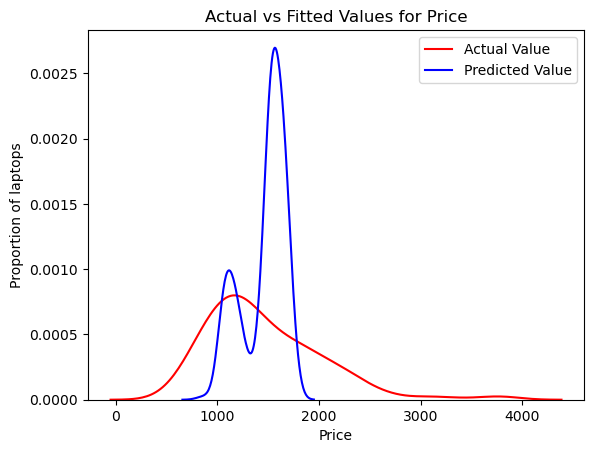

In [12]:
#画分布图
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value") #画出真实价格的分布曲线（红色）
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values", ax=ax1) #画出一条预测值的分布曲线（蓝色）。
plt.title('Actual vs Fitted Values for Price') #是给整张当前图（同一个 Axes）加标题、坐标轴标签和图例，所以这两条曲线共享同一个标题和坐标轴。
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()


In [20]:

#计算MSE和R^2
mse_slr = mean_squared_error(df['Price'], Yhat)
r2_score_slr = lm.score(X, Y)
print('The R-square for Linear Regression is: ', r2_score_slr)
print('The mean square error of price and predicted value is: ', mse_slr)

The R-square for Linear Regression is:  0.13444363210243238
The mean square error of price and predicted value is:  284583.44058686297


Task 2 - Multiple Linear Regression

In [21]:
#建立模型
lm1 = LinearRegression()
Z = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]
lm1.fit(Z,Y)
Y_hat = lm1.predict(Z)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_73592\527658282.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_73592\527658282.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

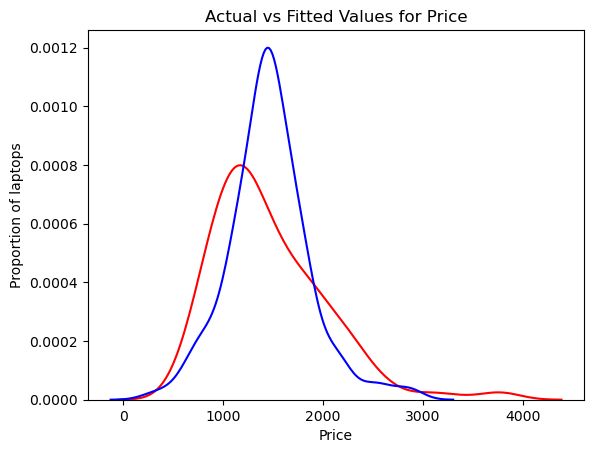

In [22]:
#画分布图
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.show()


In [25]:
#计算MSE和R^2

r2 = lm1.score(Z, df['Price'])  # 计算 R^2 # 等价于 r2_score(df['price'], lm1.predict(Z))
print('The R-square is: ', r2)

y_hat_multi = lm1.predict(Z) # 先得到预测值
mse = mean_squared_error(df['Price'], y_hat_multi) # 计算 MSE
print('The MSE is: ', mse)

The R-square is:  0.5082509055187374
The MSE is:  161680.5726389311


Task 3 - Polynomial Regression

In [26]:
#看这几种的拟合情况。用变量 CPU_frequency 当作自变量 X。对同一组数据，分别拟合 3 种不同阶数的多项式（1 次、3 次、5 次）。然后把每个多项式的拟合结果跟原始数据点画在一起，看拟合好不好、有没有过拟合。
X = X.to_numpy().flatten() #把原来可能是 pandas 的 Series / DataFrame 的 X（CPU_frequency）转换成 NumPy 一维数组。 to_numpy()：从 pandas 变成 ndarray。.flatten()：展平成一维数组，形状变成 (n,)，方便 np.polyfit 使用。
f1 = np.polyfit(X, Y, 1) #用 np.polyfit 对数据 (X,Y) 做1 次多项式拟合（其实就是普通线性回归）。
p1 = np.poly1d(f1) #把系数数组 f1 封装成一个“多项式函数对象” p1，之后可以 p1(x) 直接算预测值，也可以拿去画线。

f3 = np.polyfit(X, Y, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, Y, 5)
p5 = np.poly1d(f5)


In [28]:
#画图
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

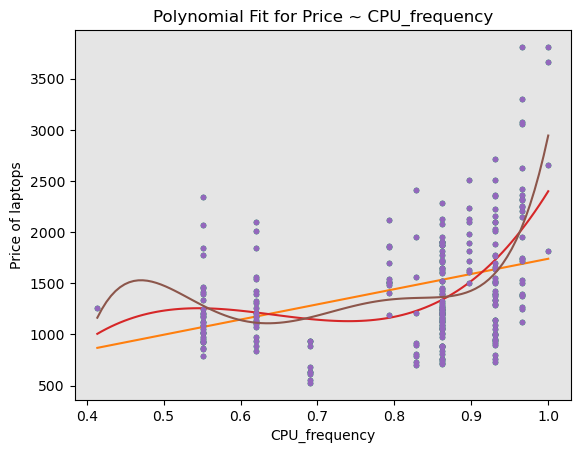

In [29]:
#Call this function for the 3 models created and get the required graphs.
PlotPolly(p1, X, Y, 'CPU_frequency')
PlotPolly(p3, X, Y, 'CPU_frequency')
PlotPolly(p5, X, Y, 'CPU_frequency')

In [36]:
#计算MSE和R^2
r_squared_1 = r2_score(Y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(Y,p1(X)))
r_squared_3 = r2_score(Y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(Y,p3(X)))
r_squared_5 = r2_score(Y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(Y,p5(X)))


The R-square value for 1st degree polynomial is:  0.1344436321024326
The MSE value for 1st degree polynomial is:  284583.4405868629
The R-square value for 3rd degree polynomial is:  0.2669264079653114
The MSE value for 3rd degree polynomial is:  241024.86303848762
The R-square value for 5th degree polynomial is:  0.3030822706443952
The MSE value for 5th degree polynomial is:  229137.29548053336


Task 4 - Pipeline

In [41]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)

In [42]:
#计算MSE和R^2
print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(Y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(Y, ypipe))

MSE for multi-variable polynomial pipeline is:  120595.86128028372
R^2 for multi-variable polynomial pipeline is:  0.6332094535859658
